In [ ]:
import tensorflow as tf
from tensorflow import keras
import tensorflow_addons as tfa
import tensorflow_hub as hub
from sklearn.metrics import mean_absolute_error
import numpy as np
import datetime

c:\Users\SIA\anaconda3\envs\deepface-env\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


### Load data

In [ ]:
train_ds = tf.data.experimental.load('./data/fullscene/train_ds') \
    .cache().shuffle(buffer_size=1000, seed=42).prefetch(buffer_size=tf.data.AUTOTUNE)

valid_ds = tf.data.experimental.load('./data/fullscene/val_ds') \
    .cache().shuffle(buffer_size=1000, seed=42).prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds, valid_ds

Instructions for updating:
Use `tf.data.Dataset.load(...)` instead.


(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 10, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 10, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>)

### Load VGG16

In [ ]:
vgg16 = keras.applications.VGG16(include_top=False, weights='imagenet', pooling='max')
vgg16.trainable = False

### Load Vit-B16

In [ ]:
vit_extractor = hub.KerasLayer("https://www.kaggle.com/models/spsayakpaul/vision-transformer/frameworks/TensorFlow2/variations/vit-b16-fe/versions/1/", trainable=False) # ../../vit_b16_fe/


## Build scene model

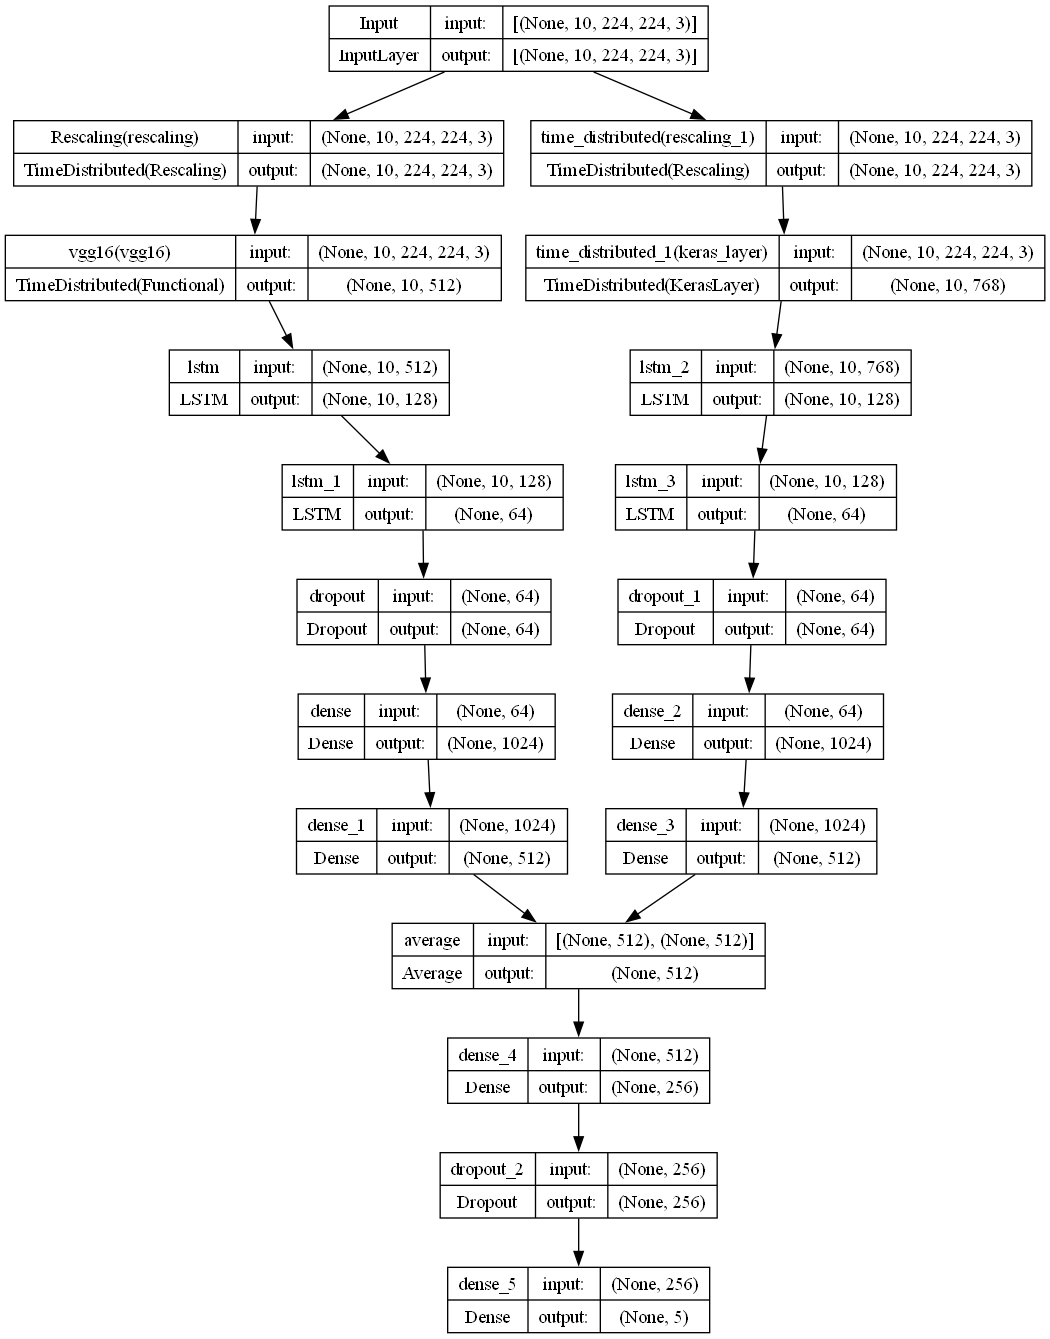

In [ ]:
inputs = keras.layers.Input(shape=(10,224,224,3), name='Input')

# First model
x      = keras.layers.TimeDistributed(keras.layers.Rescaling(scale=1./255.0), name='Rescaling')(inputs)
x      = keras.layers.TimeDistributed(vgg16, name='vgg16')(x)
x      = keras.layers.LSTM(units=128, return_sequences=True)(x)
x      = keras.layers.LSTM(units=64)(x)
x      = keras.layers.Dropout(0.2)(x)

x      = keras.layers.Dense(units=1024)(x)
x      = keras.layers.Dense(units=512, activation='relu')(x)


# Second model
y      = keras.layers.TimeDistributed(keras.layers.Rescaling(scale=1./127.5, offset=-1))(inputs)

#vit_extractor = hub.KerasLayer("https://www.kaggle.com/models/spsayakpaul/vision-transformer/frameworks/TensorFlow2/variations/vit-b16-fe/versions/1/", trainable=False) # ../../vit_b16_fe/
vit_extractor.compute_output_shape = lambda x: (x[0], 768)

y      = keras.layers.TimeDistributed(vit_extractor)(y)
y      = keras.layers.LSTM(units=128, return_sequences=True)(y)
y      = keras.layers.LSTM(units=64)(y)
y      = keras.layers.Dropout(0.2)(y)
y      = keras.layers.Dense(units=1024)(y)
y      = keras.layers.Dense(units=512, activation='relu')(y)


# Averaget two models
z      = keras.layers.Average()([x,y])

z      = keras.layers.Dense(256, activation='relu')(z)
z      = keras.layers.Dropout(0.5)(z)

z      = keras.layers.Dense(5, activation='sigmoid')(z)

model  = keras.models.Model(inputs=inputs, outputs=z)
keras.utils.plot_model(model, show_shapes=True)

### Compile model

In [ ]:
t = datetime.datetime.now().strftime("%m%d_%H%M%S")

optimizer      = tfa.optimizers.RectifiedAdam()

early_stopping = keras.callbacks.EarlyStopping(patience=10, verbose=0)
check_point    = keras.callbacks.ModelCheckpoint(filepath='./weights/scene/scene.t5',
                             monitor='val_mae',
                             mode='min',
                             save_best_only=True,
                             save_weights_only=True,
                             verbose=0)

model.compile(loss='mse', optimizer=optimizer, metrics=['mae'])

### Train

In [ ]:
history = model.fit(train_ds, validation_data=valid_ds, batch_size=8, epochs=100, callbacks=[early_stopping, check_point])

Epoch 1/100
1/1 [==============================] - 59s 59s/step - loss: 0.0328 - mae: 0.1684 - val_loss: 0.0131 - val_mae: 0.1051
Epoch 2/100
1/1 [==============================] - 18s 18s/step - loss: 0.0337 - mae: 0.1696 - val_loss: 0.0131 - val_mae: 0.1051
Epoch 3/100
1/1 [==============================] - 15s 15s/step - loss: 0.0334 - mae: 0.1696 - val_loss: 0.0131 - val_mae: 0.1051
Epoch 4/100
1/1 [==============================] - 21s 21s/step - loss: 0.0339 - mae: 0.1716 - val_loss: 0.0131 - val_mae: 0.1051
Epoch 5/100
1/1 [==============================] - 26s 26s/step - loss: 0.0329 - mae: 0.1668 - val_loss: 0.0131 - val_mae: 0.1051
Epoch 6/100
1/1 [==============================] - 27s 27s/step - loss: 0.0334 - mae: 0.1677 - val_loss: 0.0129 - val_mae: 0.1043
Epoch 7/100
1/1 [==============================] - 15s 15s/step - loss: 0.0321 - mae: 0.1654 - val_loss: 0.0127 - val_mae: 0.1032
Epoch 8/100
1/1 [==============================] - 18s 18s/step - loss: 0.0314 - mae: 0.16

## Train Evaluation

### Load weights

In [ ]:
model.load_weights('./weights/scene/scene.t5')


## Evaluation

### Validation data

In [ ]:
valid_ds = tf.data.experimental.load('./data/fullscene/val_ds')
valid_ds

loss, mae = model.evaluate(valid_ds)
(1-mae)*100

1/1 [==============================] - 4s 4s/step - loss: 0.0013 - mae: 0.0273


97.2712803632021

In [ ]:
y_true = np.concatenate([y for x,y in valid_ds])
y_pred = model.predict(valid_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

1/1 [==============================] - 8s 8s/step


(array([94.376755, 99.71094 , 99.52007 , 94.67089 , 98.077736],
       dtype=float32),
 97.2712803632021)

### Test data

In [ ]:
test_ds = tf.data.experimental.load('./data/fullscene/test_ds/')
loss, mae = model.evaluate(test_ds)
(1-mae)*100

1/1 [==============================] - 4s 4s/step - loss: 0.0068 - mae: 0.0726


92.74319410324097

In [ ]:
y_true = np.concatenate([y for x,y in test_ds], axis=0)
y_pred = model.predict(test_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae)) * 100

1/1 [==============================] - 4s 4s/step


(array([87.43361, 90.29361, 96.32648, 97.9722 , 91.69007], dtype=float32),
 92.74319410324097)